<a href="https://colab.research.google.com/github/Nobodybutyouu/FBD_detection_models/blob/main/FBD_detection_Lenet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lenet5**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

In [3]:
!cp -r "/content/drive/MyDrive/ricePlant_dataSet" "/content/"

train_dir = "/content/drive/MyDrive/ricePlant_dataSet/train"
test_dir  = "/content/drive/MyDrive/ricePlant_dataSet/test"

print("Dataset copied to local runtime")

Dataset copied to local runtime


In [4]:

IMG_SIZE = 32          # LeNet-5 uses 32x32
BATCH_SIZE = 32
EPOCHS = 50

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',   # LeNet-5 originally grayscale
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)



Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Classes: ['Healthy_images', 'Unhealthy_images']


In [5]:
model = Sequential([
    Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(32,32,1)),
    AveragePooling2D(pool_size=(2,2), strides=2),

    Conv2D(16, kernel_size=(5,5), activation='tanh'),
    AveragePooling2D(pool_size=(2,2), strides=2),

    Flatten(),

    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,026 (238.38 KB)

 Trainable params: 61,026 (238.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.4897 - loss: 0.7244 - val_accuracy: 0.5000 - val_loss: 0.7145
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5153 - loss: 0.6941 - val_accuracy: 0.6900 - val_loss: 0.6697
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.5958 - loss: 0.6725 - val_accuracy: 0.6400 - val_loss: 0.6323
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6316 - loss: 0.6473 - val_accuracy: 0.5650 - val_loss: 0.6550
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6297 - loss: 0.6408 - val_accuracy: 0.6400 - val_loss: 0.6090
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.6403 - loss: 0.6310 - val_accuracy: 0.6750 - val_loss: 0.6177
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6979 - loss: 0.6085 - val_accuracy: 0.6800 - val_loss: 0.6221
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6514 - loss: 0.6341 - val_accuracy: 0.6850 - val_loss:

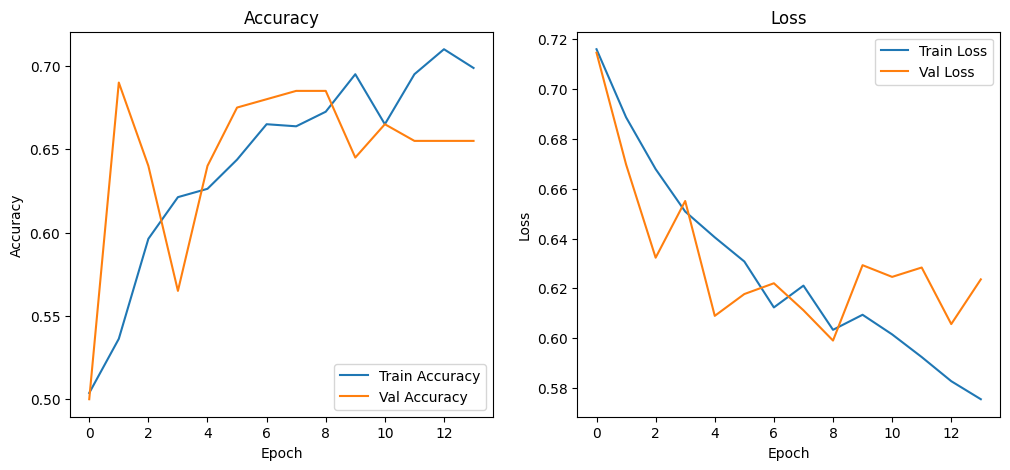

In [7]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [8]:
y_true = test_generator.classes

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


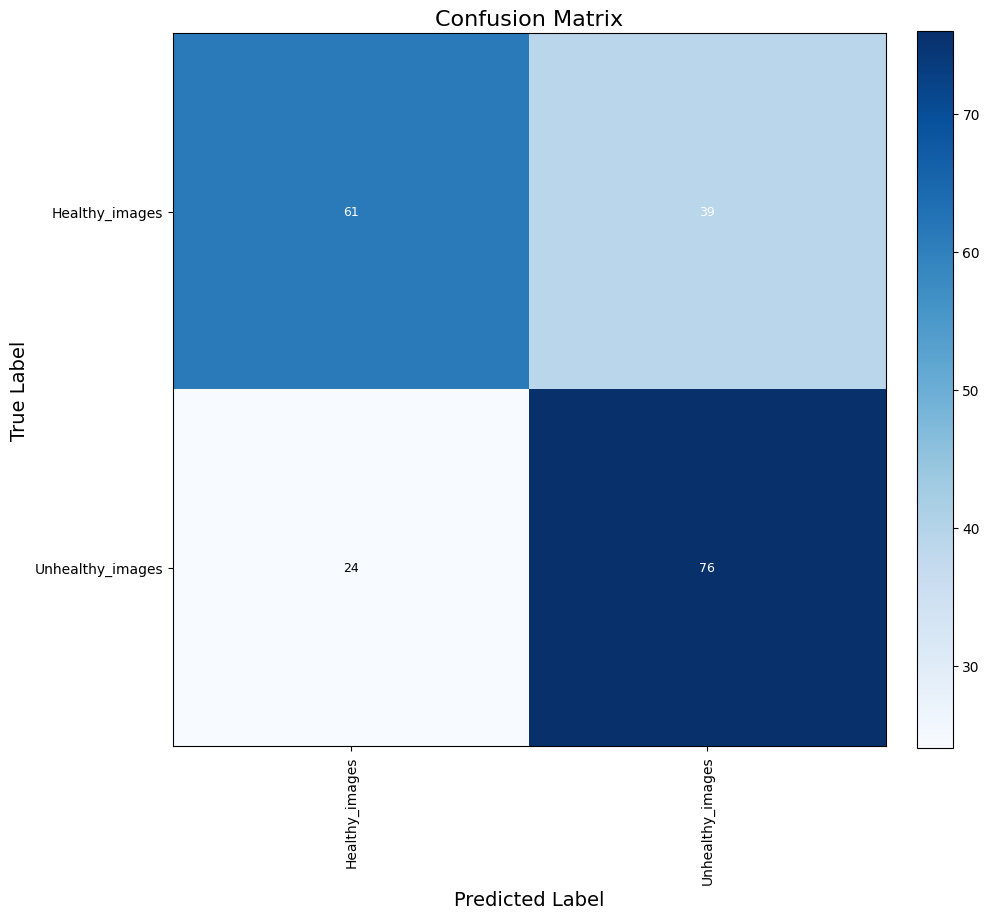

Classification Report:

                  precision    recall  f1-score   support

  Healthy_images     0.7176    0.6100    0.6595       100
Unhealthy_images     0.6609    0.7600    0.7070       100

        accuracy                         0.6850       200
       macro avg     0.6893    0.6850    0.6832       200
    weighted avg     0.6893    0.6850    0.6832       200



In [9]:
#Step 9

def plot_confusion_matrix(cm, class_names):
    num_classes = len(class_names)

    fig_size = max(10, num_classes * 0.7)
    plt.figure(figsize=(fig_size, fig_size))

    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", fontsize=16)
    plt.colorbar(fraction=0.046, pad=0.04)

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_names, rotation=90, fontsize=10)
    plt.yticks(tick_marks, class_names, fontsize=10)

    thresh = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                fontsize=9,
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, class_names)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

In [10]:
import tensorflow as tf
tf.keras.backend.clear_session()